In [ ]:
!pip install groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.7 MB/s eta 0:00:00


In [ ]:
import sqlite3
import pandas as pd
import os
from groq import Groq
import re

In [ ]:
import os
os.environ['GROQ_API_KEY'] = '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'
client = Groq(api_key = os.environ['GROQ_API_KEY'])
MODEL = 'llama-3.1-8b-instant'
print("Groq client initialized successfully!")
print(f"Using Model: {MODEL}")

Groq client initialized successfully!
Using Model: llama-3.1-8b-instant


In [ ]:
import io
df = pd.read_csv('student_performance.csv')
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [ ]:
conn = sqlite3.connect("college.db")
df.to_sql("students", conn, if_exists="replace", index = False)

test_df = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM students", conn)
print(f"Verification: {test_df['total_rows'][0]} rows in database")
test_df

Verification: 30 rows in database


,total_rows
0,30


In [ ]:
def get_schema(conn, table_name = "students"):
  """
  This function reads the structure of a database table.
  It returns information about each column: name and data.

  Parameters:
    conn: The SQLite connection object.
    table_name: The name of the table to inspect.

  Returns:
    A formatted string describing the table structure.
  """
  cursor = conn.cursor()
  cursor.execute(f"PRAGMA table_info({table_name})")
  columns = cursor.fetchall()
  schema_lines = [f"Table: {table_name}"]
  schema_lines.append("Columns:")

  for col in columns:
    schema_lines.append(f"  - {col[1]} ({col[2]})")
  cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")

  sample_rows = cursor.fetchall()
  schema_lines.append("\nSample rows (first 3): ")

  for row in sample_rows:
    schema_lines.append(f"  {row}")

  return "\n".join(schema_lines)
schema = get_schema(conn)
print(schema)

Table: students
Columns:
  - student_id (INTEGER)
  - name (TEXT)
  - age (INTEGER)
  - gender (TEXT)
  - department (TEXT)
  - semester (INTEGER)
  - math_score (INTEGER)
  - science_score (INTEGER)
  - english_score (INTEGER)
  - programming_score (INTEGER)
  - attendance_percentage (INTEGER)
  - city (TEXT)
  - admission_year (INTEGER)

Sample rows (first 3): 
  (1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
  (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
  (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [ ]:
def generate_sql(user_question, schema_text, client, model):
  """
  Sends the user's question and database to the Groq.
  The LLM generates a SQL query that answers the question
  """

  system_prompt = f"""You are an expert SQL Assistant.
  You are connected to a SQLIte database with the following structure
{schema_text}

Rules you must follow:
1. Generate ONLY a valid SQLite SQL query.
2. Do not include any explanation or text — only the SQL query.
3. Do not use markdown code blocks. Return the raw SQL only.
4. The table name is: students
5. Only use column names that exist in the schema above.
6. Use single quotes for string values in WHERE clauses (example: WHERE subject = 'Programming').
7. If the user asks for top N, use ORDER BY marks DESC LIMIT N.
"""
  response = client.chat.completions.create(
      model = model,
      messages = [
       {"role" : "system", "content": system_prompt},
       {"role" : "user", "content": user_question}
      ],
      temperature = 0.0
  )
  sql_query = response.choices[0].message.content.strip()
  return sql_query

question = "Show me students with name, gender, department and city who have attendance percentage greater than 90 "
print(f"Question: {question}")

sql = generate_sql(question, schema, client, MODEL)
print(f"Generated SQL Query: {sql}")

Question: Show me students with name, gender, department and city who have attendance percentage greater than 90 
Generated SQL Query: SELECT name, gender, department, city FROM students WHERE attendance_percentage > 90


In [ ]:
def execute_sql(sql_query, conn):
  """
  Cleans the AI generated SQL and execute it on the SQLite database
  """
  clean_sql = sql_query.strip()
  clean_sql = re.sub(r'```sql\s*','',clean_sql)
  clean_sql = re.sub(r'```sql\s*','',clean_sql)
  clean_sql = clean_sql.strip()

  try:
    result_df = pd.read_sql_query(clean_sql, conn)
    return result_df, None
  except Exception as e:
    return None, str(e)
print(f"Executing SQL: {sql}")
result, error = execute_sql(sql, conn)

if error:
  print(f"Error: {error}")
else:
  print(f"\nQuery returned {len(result)} rows:")
  print(result)

Executing SQL: SELECT name, gender, department, city FROM students WHERE attendance_percentage > 90

Query returned 10 rows:
             name  gender        department       city
0    Aarav Sharma    Male  Computer Science     Mumbai
1     Sneha Reddy  Female        Mechanical  Hyderabad
2     Divya Singh  Female  Computer Science    Lucknow
3      Ananya Das  Female  Computer Science    Kolkata
4   Kavya Nambiar  Female        Mechanical   Thrissur
5    Ritu Agarwal  Female       Electronics       Agra
6  Swati Kulkarni  Female  Computer Science     Nagpur
7     Tanvi Mehta  Female  Computer Science      Surat
8       Amit Bose    Male  Computer Science    Kolkata
9  Akanksha Yadav  Female  Computer Science       Agra


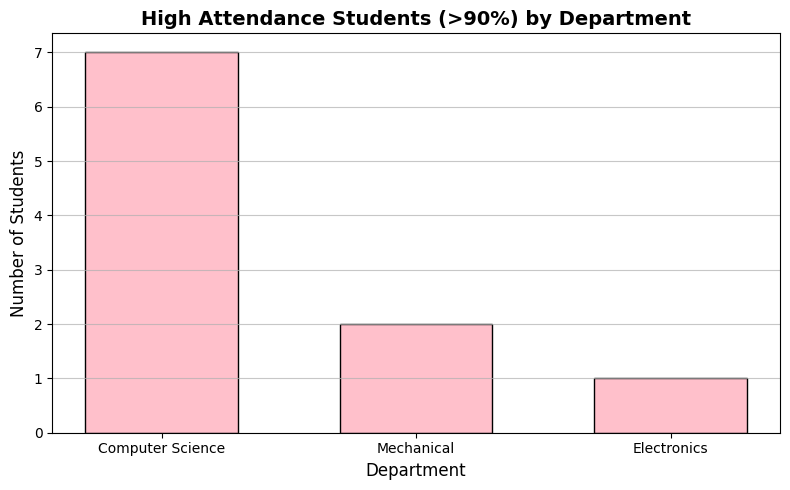

In [ ]:
import matplotlib.pyplot as plt
dept_counts = result['department'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(dept_counts.index, dept_counts.values, color='pink', edgecolor='black', width=0.6)

plt.title('High Attendance Students (>90%) by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
def text_to_sql_agent(user_question, conn, client, model, verbose = True):
  """
  The main AI Agent function,
  Takes a user questionin plain English and returns database results.

  This is the complete workflow:
  1. Get database schema
  2. Generate SQL using Groq LLM
  3. Execute SQL on the database
  4. Format and return results
  """
  print(f"USER QUESTION: {user_question}")
  print()

  if verbose:
    print("\n[STEP 1] Reading database schema...")

  schema_text = get_schema(conn)

  if verbose:
    print("Schema loaded successfully!")

  if verbose:
    print("\n[STEP 2] Generating SQL query with Groq LLM...")
    generated_sql = generate_sql(user_question, schema_text, client, model)
  if verbose:
    print(f"Generated SQL: {generated_sql}")

  if verbose:
    print("\n[STEP 3] Executing SQL on the database...")

  result_df, error = execute_sql(generated_sql, conn)
  if error:
    print(f"SQL Execution error: {error}")
    return None, generated_sql

  if verbose:
    print(f"\n[STEP 4] Query returned {len(result_df)} row(s)")
    print("\nRESULTS:")
    print("-"*40)
    print(result_df.to_string(index = False))
  print("="*60)
  return result_df, generated_sql

result, sql_used = text_to_sql_agent(
    "Show top 3 students in Programming",
    conn, client, MODEL
)

USER QUESTION: Show top 3 students in Programming


[STEP 1] Reading database schema...
Schema loaded successfully!

[STEP 2] Generating SQL query with Groq LLM...
Generated SQL: SELECT name FROM students ORDER BY programming_score DESC LIMIT 3

[STEP 3] Executing SQL on the database...

[STEP 4] Query returned 3 row(s)

RESULTS:
----------------------------------------
       name
 Ananya Das
Tanvi Mehta
 Arjun Nair
